# Notebook 1 — Ethanol MD Simulation with GAFF2

This notebook demonstrates how to set up and run a molecular dynamics simulation of
liquid ethanol using the **GAFF2** (General AMBER Force Field 2) classical force field
in **OpenMM**.

## Outline
1. Build an ethanol molecule from its SMILES string
2. Pack ~200 molecules into a periodic box at near-experimental density
3. Parameterize the system with GAFF2 (AM1-BCC charges)
4. Energy minimization
5. NPT equilibration (298.15 K, 1 bar)
6. NVT production run — save unwrapped trajectory for diffusion analysis

The output trajectory (`gaff2_production.dcd`) and topology (`gaff2_topology.pdb`)
will be used in **Notebook 3** to compute the mean-squared displacement (MSD) and
extract the self-diffusion coefficient.

## 0. Imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np

import openmm
import openmm.app as app
import openmm.unit as unit

from openff.toolkit import Molecule
from openff.interchange.components._packmol import pack_box
from openff.units import unit as offunit

from openmmforcefields.generators import GAFFTemplateGenerator

print(f"OpenMM version : {openmm.__version__}")

OpenMM version : 8.2


## 1. Build the ethanol molecule

We create ethanol from its SMILES representation (`CCO`) using the
OpenFF Toolkit, which also generates an initial 3-D conformer.

In [2]:
ethanol = Molecule.from_smiles("CCO")
ethanol.generate_conformers(n_conformers=1)
print(f"Ethanol: {ethanol.to_smiles()} — {ethanol.n_atoms} atoms")

Ethanol: [H][O][C]([H])([H])[C]([H])([H])[H] — 9 atoms


## 2. Pack a liquid box

We use Packmol (via OpenFF Interchange) to place **200 ethanol molecules** in a
cubic box.  The box length is chosen so the initial density is close to the
experimental value of 0.789 g/cm$^3$ at 298 K.

Ethanol molar mass ≈ 46.07 g/mol.  For 200 molecules:

$$V = \frac{N \cdot M}{\rho \cdot N_A}
    = \frac{200 \times 46.07}{0.789 \times 6.022 \times 10^{23}}
    \approx 19.4\;\text{nm}^3
    \;\Rightarrow\; L \approx 2.69\;\text{nm}$$

We round up slightly to 2.8 nm to give Packmol room.

In [3]:
N_MOLECULES = 200
BOX_LENGTH = 2.8  # nm

topology = pack_box(
    molecules=[ethanol],
    number_of_copies=[N_MOLECULES],
    box_vectors=BOX_LENGTH * np.eye(3) * offunit.nanometer,
)

print(f"Packed {N_MOLECULES} ethanol molecules")
print(f"Total atoms: {topology.n_atoms}")
print(f"Box vectors (nm):\n{topology.box_vectors}")

Packed 200 ethanol molecules
Total atoms: 1800
Box vectors (nm):
[[2.8 0.0 0.0] [0.0 2.8 0.0] [0.0 0.0 2.8]] nanometer


## 3. Parameterize with GAFF2

The `GAFFTemplateGenerator` from the `openmmforcefields` package assigns
GAFF2 atom types and generates AM1-BCC partial charges on the fly.  We
register it with an OpenMM `ForceField` object so that it can resolve
any residue template that is not already known.

In [4]:
gaff = GAFFTemplateGenerator(
    molecules=ethanol,
    forcefield="gaff-2.11",
)

forcefield = app.ForceField()
forcefield.registerTemplateGenerator(gaff.generator)

omm_topology = topology.to_openmm()
positions = topology.get_positions().to(offunit.nanometer).magnitude * unit.nanometer

system = forcefield.createSystem(
    omm_topology,
    nonbondedMethod=app.PME,
    nonbondedCutoff=1.0 * unit.nanometer,
    constraints=app.HBonds,
)

print(f"System created with {system.getNumParticles()} particles")
print(f"Number of forces: {system.getNumForces()}")
for i in range(system.getNumForces()):
    print(f"  {system.getForce(i).__class__.__name__}")

System created with 1800 particles
Number of forces: 5
  HarmonicBondForce
  PeriodicTorsionForce
  NonbondedForce
  CMMotionRemover
  HarmonicAngleForce


## 4. Energy minimization

Packmol-generated configurations can have steric clashes.  A short energy
minimization removes these before dynamics.

In [5]:
integrator = openmm.LangevinMiddleIntegrator(
    298.15 * unit.kelvin,
    1.0 / unit.picosecond,
    2.0 * unit.femtosecond,
)

# Use CUDA if available; fall back to CPU
try:
    platform = openmm.Platform.getPlatformByName("CUDA")
    properties = {"Precision": "mixed"}
    print("Using CUDA platform")
except Exception:
    platform = openmm.Platform.getPlatformByName("CPU")
    properties = {}
    print("Using CPU platform (this will be slow)")

simulation = app.Simulation(omm_topology, system, integrator, platform)
simulation.context.setPositions(positions)

print("Initial potential energy:",
      simulation.context.getState(getEnergy=True).getPotentialEnergy())

simulation.minimizeEnergy(maxIterations=5000)

print("After minimization:     ",
      simulation.context.getState(getEnergy=True).getPotentialEnergy())

Using CUDA platform
Initial potential energy: 6276.2355121158 kJ/mol
After minimization:      -8293.752945563949 kJ/mol


## 5. NPT equilibration

We equilibrate the box volume at **298.15 K** and **1 bar** using a
Monte Carlo barostat.  This lets the density relax to the force-field
equilibrium value.

**Duration:** 500 ps (250,000 steps at 2 fs).  Adjust if needed.

In [6]:
TEMPERATURE = 298.15 * unit.kelvin
PRESSURE = 1.0 * unit.bar
NPT_STEPS = 250_000       # 500 ps at 2 fs/step
NPT_REPORT_INTERVAL = 5000  # every 10 ps

barostat = openmm.MonteCarloBarostat(PRESSURE, TEMPERATURE, 25)
system.addForce(barostat)
simulation.context.reinitialize(preserveState=True)

simulation.reporters.append(
    app.StateDataReporter(
        "gaff2_npt_log.csv",
        NPT_REPORT_INTERVAL,
        step=True,
        time=True,
        potentialEnergy=True,
        kineticEnergy=True,
        temperature=True,
        volume=True,
        density=True,
    )
)

print(f"Running NPT equilibration for {NPT_STEPS} steps ...")
simulation.step(NPT_STEPS)
print("NPT equilibration complete.")

state = simulation.context.getState(getPositions=True, enforcePeriodicBox=True)
box = state.getPeriodicBoxVectors()
print(f"Equilibrated box vectors (nm):")
for v in box:
    print(f"  {v}")

Running NPT equilibration for 250000 steps ...
NPT equilibration complete.
Equilibrated box vectors (nm):
  Vec3(x=2.7275903623179922, y=0.0, z=0.0) nm
  Vec3(x=0.0, y=2.7275903623179922, z=0.0) nm
  Vec3(x=0.0, y=0.0, z=2.7275903623179922) nm


### Quick check — density during NPT

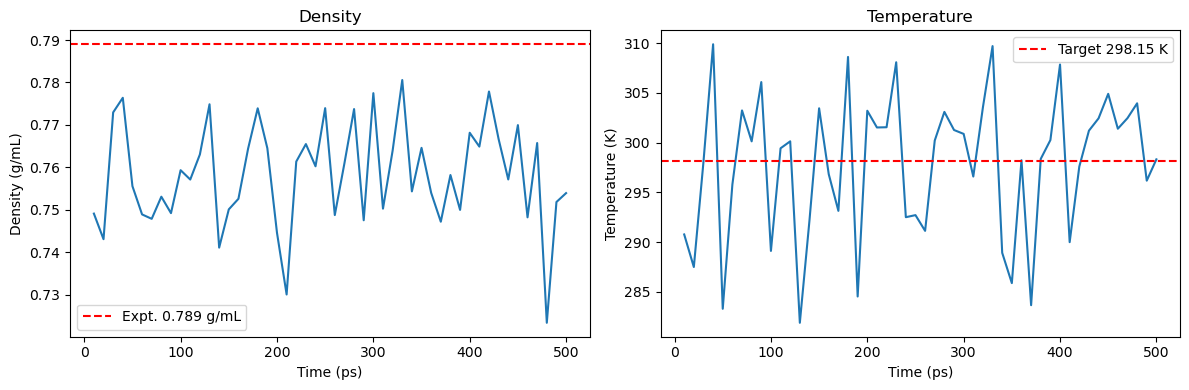

In [7]:
import matplotlib.pyplot as plt

npt_data = np.genfromtxt("gaff2_npt_log.csv", delimiter=",", names=True, skip_header=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(npt_data["Time_ps"], npt_data["Density_gmL"])
axes[0].axhline(0.789, color="red", ls="--", label="Expt. 0.789 g/mL")
axes[0].set_xlabel("Time (ps)")
axes[0].set_ylabel("Density (g/mL)")
axes[0].legend()
axes[0].set_title("Density")

axes[1].plot(npt_data["Time_ps"], npt_data["Temperature_K"])
axes[1].axhline(298.15, color="red", ls="--", label="Target 298.15 K")
axes[1].set_xlabel("Time (ps)")
axes[1].set_ylabel("Temperature (K)")
axes[1].legend()
axes[1].set_title("Temperature")

plt.tight_layout()
plt.savefig("gaff2_npt_equilibration.png", dpi=150)
plt.show()

## 6. Save equilibrated topology

We save the equilibrated configuration as a PDB file.  This will be
re-used in **Notebook 2** (MACE simulation) and **Notebook 3** (analysis).

In [8]:
state = simulation.context.getState(getPositions=True, enforcePeriodicBox=True)
positions_eq = state.getPositions()

with open("gaff2_topology.pdb", "w") as f:
    app.PDBFile.writeFile(omm_topology, positions_eq, f)

print("Saved gaff2_topology.pdb")

Saved gaff2_topology.pdb


## 7. NVT production run

For computing the self-diffusion coefficient we run in the **NVT** ensemble
(constant volume) so that box-size fluctuations do not complicate the MSD.

**Critical:** We save the trajectory with `enforcePeriodicBox=False` so that
atom coordinates are *unwrapped* — molecules that cross a periodic boundary
continue in the same direction rather than being folded back.  This is
essential for a correct MSD calculation.

**Duration:** 2 ns (1,000,000 steps at 2 fs).  Frames saved every 1 ps.

In [9]:
# Remove the barostat for NVT
for i in range(system.getNumForces() - 1, -1, -1):
    if isinstance(system.getForce(i), openmm.MonteCarloBarostat):
        system.removeForce(i)
        break

# Re-create integrator (integrators cannot be reused)
integrator_nvt = openmm.LangevinMiddleIntegrator(
    TEMPERATURE,
    1.0 / unit.picosecond,
    2.0 * unit.femtosecond,
)

simulation_nvt = app.Simulation(omm_topology, system, integrator_nvt, platform)
simulation_nvt.context.setPositions(positions_eq)
simulation_nvt.context.setVelocitiesToTemperature(TEMPERATURE)

NVT_STEPS = 1_000_000      # 2 ns
TRAJ_INTERVAL = 500        # save every 1 ps
LOG_INTERVAL = 5000        # log every 10 ps

simulation_nvt.reporters.append(
    app.DCDReporter("gaff2_production.dcd", TRAJ_INTERVAL, enforcePeriodicBox=False)
)
simulation_nvt.reporters.append(
    app.StateDataReporter(
        "gaff2_nvt_log.csv",
        LOG_INTERVAL,
        step=True,
        time=True,
        potentialEnergy=True,
        temperature=True,
    )
)

print(f"Running NVT production for {NVT_STEPS} steps (2 ns) ...")
simulation_nvt.step(NVT_STEPS)
print("Production run complete.")
print(f"Trajectory saved to gaff2_production.dcd")
print(f"Frames: {NVT_STEPS // TRAJ_INTERVAL}")

Running NVT production for 1000000 steps (2 ns) ...


Production run complete.
Trajectory saved to gaff2_production.dcd
Frames: 2000


### Quick sanity check — temperature during NVT

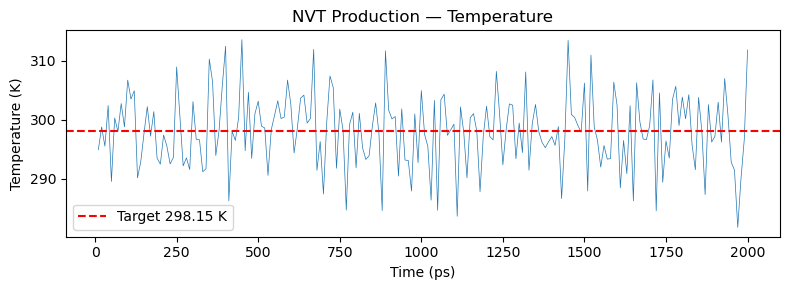

Mean T = 298.07 K
Std  T = 6.22 K


In [10]:
nvt_data = np.genfromtxt("gaff2_nvt_log.csv", delimiter=",", names=True, skip_header=0)

plt.figure(figsize=(8, 3))
plt.plot(nvt_data["Time_ps"], nvt_data["Temperature_K"], lw=0.5)
plt.axhline(298.15, color="red", ls="--", label="Target 298.15 K")
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.title("NVT Production — Temperature")
plt.legend()
plt.tight_layout()
plt.savefig("gaff2_nvt_temperature.png", dpi=150)
plt.show()

print(f"Mean T = {nvt_data['Temperature_K'].mean():.2f} K")
print(f"Std  T = {nvt_data['Temperature_K'].std():.2f} K")

## Summary

| File | Description |
|---|---|
| `gaff2_topology.pdb` | Equilibrated topology + coordinates |
| `gaff2_production.dcd` | 2 ns NVT trajectory (unwrapped coords) |
| `gaff2_npt_log.csv` | NPT equilibration thermodynamics |
| `gaff2_nvt_log.csv` | NVT production thermodynamics |

Proceed to **Notebook 2** for the MACE-OFF23 simulation, or jump directly
to **Notebook 3** for the MSD analysis.